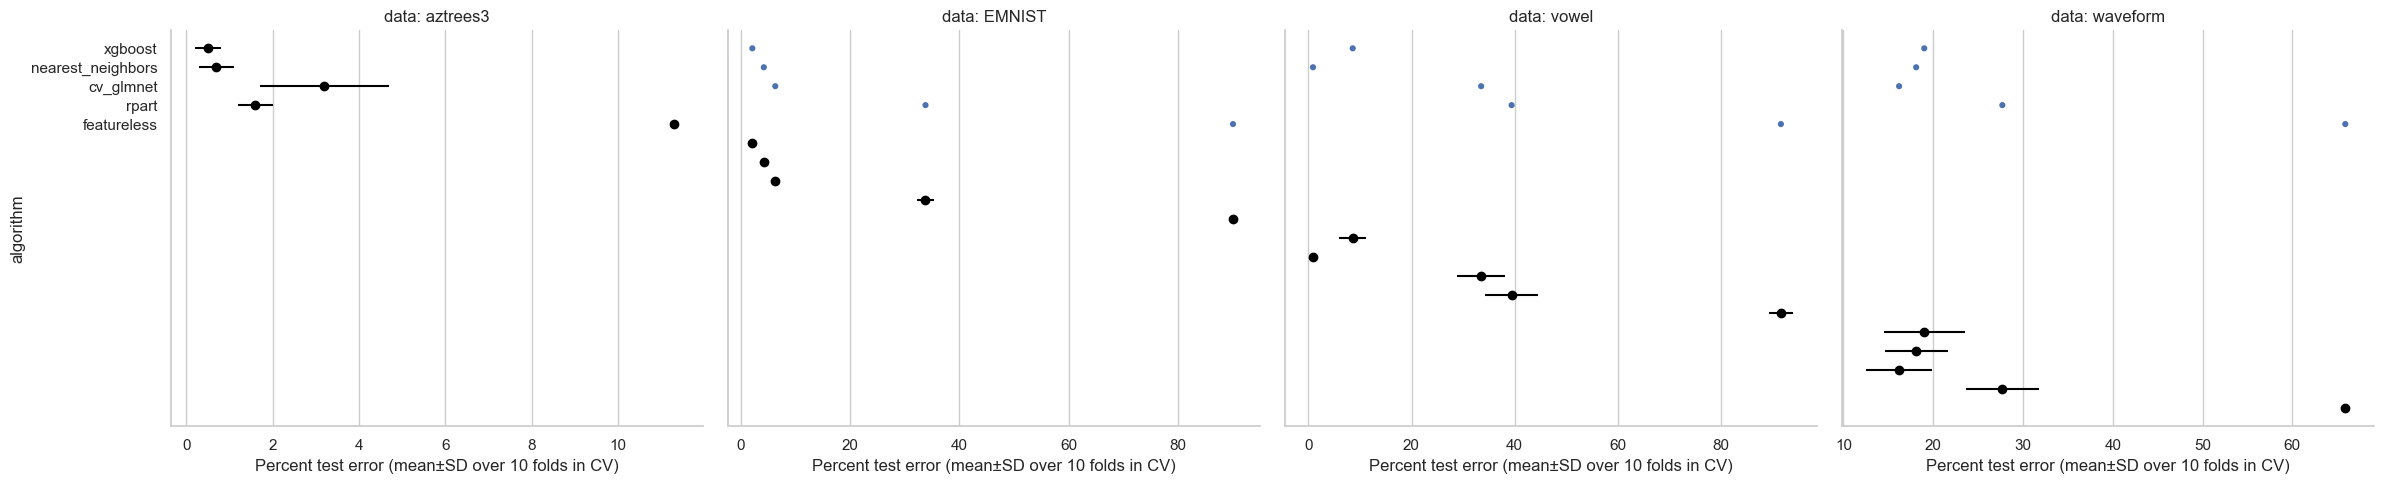

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Sample data similar to the plot
data = {
    'Algorithm': ['xgboost', 'nearest_neighbors', 'cv_glmnet', 'rpart', 'featureless'] * 4,
    'Dataset': ['aztrees3'] * 5 + ['EMNIST'] * 5 + ['vowel'] * 5 + ['waveform'] * 5,
    'Mean Error (%)': [0.5, 0.7, 3.2, 1.6, 11.3, 
                       2.1, 4.2, 6.3, 33.8, 90.1,
                       8.6, 0.9, 33.5, 39.4, 91.6,
                       19.0, 18.1, 16.2, 27.7, 65.9],
    'Standard Deviation (%)': [0.3, 0.4, 1.5, 0.4, 0.1, 
                               0.1, 0.3, 0.4, 1.6, 0.5,
                               2.6, 0.8, 4.7, 5.2, 2.3,
                               4.5, 3.5, 3.7, 4.1, 0.5]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Set up the plot style
sns.set(style="whitegrid")

# Create a facet grid with seaborn for different datasets
g = sns.FacetGrid(df, col="Dataset", height=5, aspect=1.2, sharex=False, sharey=True)
g.map_dataframe(
    sns.pointplot, x="Mean Error (%)", y="Algorithm", join=False, errorbar=None,
    capsize=0.2, scale=0.5, errwidth=1
)

# Add error bars manually using matplotlib
for ax, dataset in zip(g.axes.flat, df['Dataset'].unique()):
    subset = df[df['Dataset'] == dataset]
    for i, row in subset.iterrows():
        ax.errorbar(
            row['Mean Error (%)'], i,  # 'i' is the position on the y-axis
            xerr=row['Standard Deviation (%)'], fmt='o', color='black'
        )

# Set titles and labels
g.set_titles("data: {col_name}")
g.set_axis_labels("Percent test error (mean±SD over 10 folds in CV)", "algorithm")

plt.tight_layout()
plt.show()


In [6]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

#coffee_data = pd.read_csv(r"..\data\reduced_data_num.csv")
coffee_data = pd.read_csv(r"..\data\reduced_for_training.csv")

# Create the target column
coffee_data['target'] = coffee_data['caffeine_class'].map(lambda x: 0 if x == 'Absent' else 1)

# Store the column names before scaling
column_names = coffee_data.drop(columns=['caffeine_class', 'caffeine_percent', 'target']).columns

scaler = StandardScaler()
X_scaled_std = scaler.fit_transform(coffee_data.drop(columns=['caffeine_class', 'caffeine_percent', 'target']))
X = X_scaled_std.copy()  # Your scaled data
y = coffee_data['target']

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Evaluating Random Forest with 10-fold cross-validation for accuracy...
Evaluating Random Forest with 10-fold cross-validation for precision...
Evaluating Random Forest with 10-fold cross-validation for recall...
Evaluating Random Forest with 10-fold cross-validation for f1...
Evaluating Random Forest with 10-fold cross-validation for roc_auc...
Evaluating Logistic Regression with 10-fold cross-validation for accuracy...
Evaluating Logistic Regression with 10-fold cross-validation for precision...
Evaluating Logistic Regression with 10-fold cross-validation for recall...
Evaluating Logistic Regression with 10-fold cross-validation for f1...
Evaluating Logistic Regression with 10-fold cross-validation for roc_auc...
Evaluating Support Vector Classifier with 10-fold cross-validation for accuracy...
Evaluating Support Vector Classifier with 10-fold cross-validation for precision...
Evaluating Support Vector Classifier with 10-fold cross-validation for recall...
Evaluating Support Vector Cl

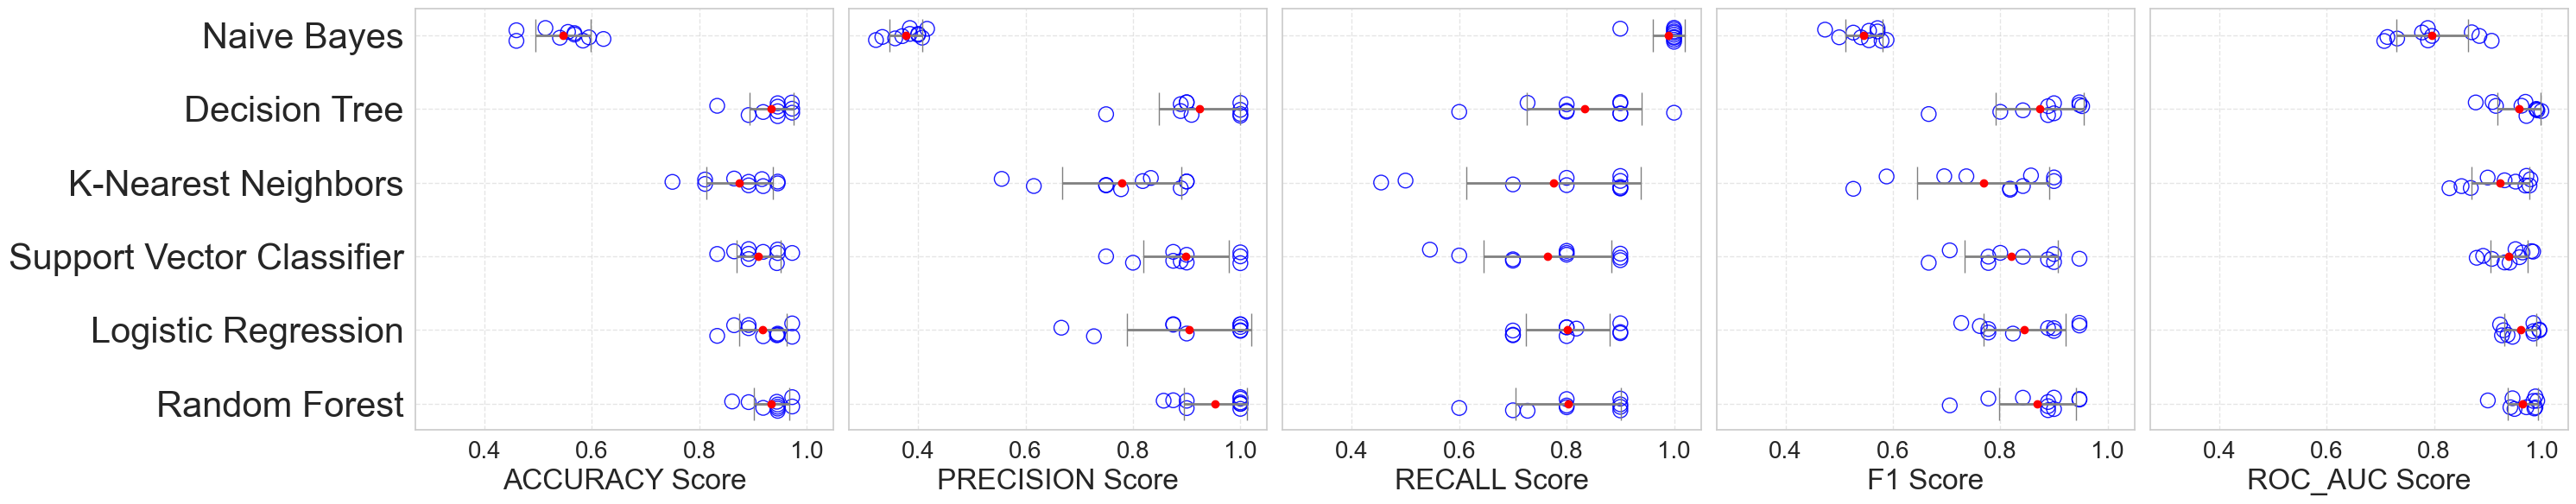

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

# Define the models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

models = [
    ('Random Forest', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('Support Vector Classifier', SVC(probability=True, random_state=42)),
    ('K-Nearest Neighbors', KNeighborsClassifier()),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Naive Bayes', GaussianNB())
]

scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
results = {metric: [] for metric in scoring_metrics}
all_scores = {metric: [] for metric in scoring_metrics}
cv_folds = 10

# Collect cross-validation results for each metric
for name, model in models:
    for metric in scoring_metrics:
        print(f"Evaluating {name} with {cv_folds}-fold cross-validation for {metric}...")
        if metric == 'roc_auc' and not hasattr(model, 'predict_proba') and not hasattr(model, 'decision_function'):
            print(f"Skipping ROC-AUC for {name} as it does not support probability estimates.")
            continue
        
        scores = cross_val_score(model, X_train, y_train, cv=cv_folds, scoring=metric)
        mean_score = np.mean(scores)
        std_score = np.std(scores)
        
        results[metric].append({'Model': name, 'Mean Score': mean_score, 'Std Dev': std_score})
        for score in scores:
            all_scores[metric].append({'Model': name, 'Score': score, 'Metric': metric})


# Convert results to DataFrames
results_df = {metric: pd.DataFrame(results[metric]) for metric in scoring_metrics}
all_scores_df = pd.DataFrame([score for metric_scores in all_scores.values() for score in metric_scores])

# Create subplots for different metrics
fig, axes = plt.subplots(1, 5, figsize=(30, 6), sharey=True)  # Adjusted for 5 subplots
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']  # Include ROC-AUC in the list

# Find the global x-axis limits for consistent scaling
all_scores_combined = all_scores_df['Score']
global_xlim = (min(all_scores_combined) - 0.05, max(all_scores_combined) + 0.05)

for ax, metric in zip(axes, scoring_metrics):
    metric_results_df = results_df[metric]
    for i, model in enumerate(metric_results_df['Model']):
        # Plot each individual cross-validation score with vertical jitter
        model_scores = all_scores_df[(all_scores_df['Model'] == model) & (all_scores_df['Metric'] == metric)]['Score']
        jittered_positions = [i + (np.random.uniform(-0.1, 0.1)) for _ in range(len(model_scores))]
        ax.scatter(model_scores, jittered_positions, edgecolor='blue', facecolors='none', alpha=0.9, s=150, label='_nolegend_')

    # Plot the mean score with error bars
    ax.errorbar(metric_results_df['Mean Score'], range(len(metric_results_df['Model'])), 
                xerr=metric_results_df['Std Dev'], fmt='o', color='red', ecolor='gray', 
                elinewidth=2, capsize=14, label='Mean ± Std Dev')

    # Set x-axis limits for consistent scaling across all subplots
    ax.set_xlim(global_xlim)

    # Customize each subplot
    ax.set_yticks(range(len(metric_results_df['Model'])))
    ax.set_yticklabels(metric_results_df['Model'], fontsize=30)  # Increase font size for y-axis labels
    ax.set_title('', fontsize=0)  # Remove the title
    ax.set_xlabel(f'{metric.upper()} Score', fontsize=24)
    ax.tick_params(axis='x', labelsize=20)
    ax.grid(True, linestyle='--', alpha=0.5)

# General plot adjustments
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()



Evaluating Random Forest Regressor with 10-fold cross-validation...
Evaluating Linear Regression with 10-fold cross-validation...
Evaluating Support Vector Regressor with 10-fold cross-validation...
Evaluating K-Nearest Neighbors Regressor with 10-fold cross-validation...
Evaluating Decision Tree Regressor with 10-fold cross-validation...


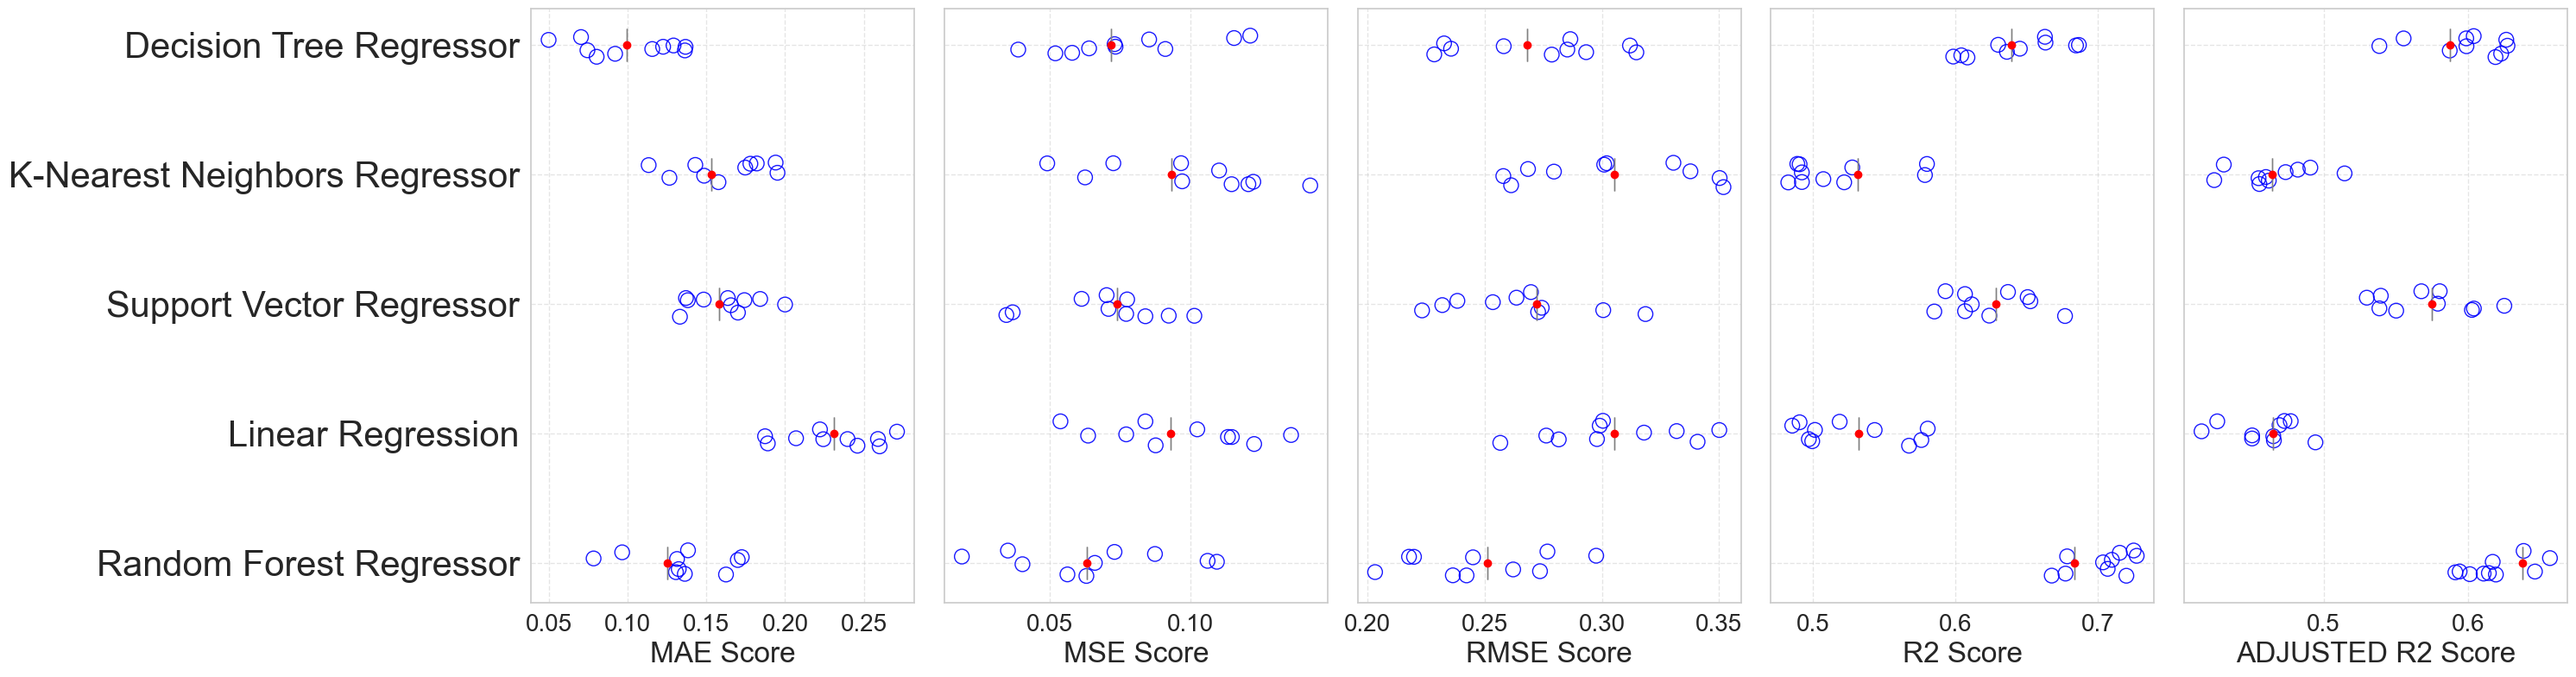

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, explained_variance_score

# Define the models
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

models = [
    ('Random Forest Regressor', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('Linear Regression', LinearRegression()),
    ('Support Vector Regressor', SVR()),
    ('K-Nearest Neighbors Regressor', KNeighborsRegressor()),
    ('Decision Tree Regressor', DecisionTreeRegressor(random_state=42))
]

# Collect results for each model and each metric
scoring_metrics = ['MAE', 'MSE', 'RMSE', 'R2', 'Adjusted R2']
results = {metric: [] for metric in scoring_metrics}
all_scores = []

cv_folds = 10
n_samples, n_features = X_train.shape

for name, model in models:
    print(f"Evaluating {name} with {cv_folds}-fold cross-validation...")
    y_pred = cross_val_predict(model, X_train, y_train, cv=cv_folds)
    
    mae = mean_absolute_error(y_train, y_pred)
    mse = mean_squared_error(y_train, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_train, y_pred)
    adjusted_r2 = 1 - (1 - r2) * (n_samples - 1) / (n_samples - n_features - 1)
    explained_var = explained_variance_score(y_train, y_pred)
    
    results['MAE'].append({'Model': name, 'Mean Score': mae, 'Std Dev': 0})  # Replace 0 with actual std dev if needed
    results['MSE'].append({'Model': name, 'Mean Score': mse, 'Std Dev': 0})
    results['RMSE'].append({'Model': name, 'Mean Score': rmse, 'Std Dev': 0})
    results['R2'].append({'Model': name, 'Mean Score': r2, 'Std Dev': 0})
    results['Adjusted R2'].append({'Model': name, 'Mean Score': adjusted_r2, 'Std Dev': 0})
    
    all_scores.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'Adjusted R2': adjusted_r2,
        'Explained Variance': explained_var
    })

# Convert results to DataFrames
results_df = {metric: pd.DataFrame(results[metric]) for metric in scoring_metrics}
all_scores_df = pd.DataFrame([score for metric_scores in all_scores for metric, score in metric_scores.items() if metric in scoring_metrics])

# Create subplots for different metrics
fig, axes = plt.subplots(1, 5, figsize=(30, 8), sharey=True)

for ax, metric in zip(axes, scoring_metrics):
    metric_results_df = results_df[metric]
    for i, model in enumerate(metric_results_df['Model']):
        # Generate random scores to simulate cross-validation distribution (use actual CV results if available)
        scores = [metric_results_df.loc[metric_results_df['Model'] == model, 'Mean Score'].values[0] + np.random.uniform(-0.05, 0.05) for _ in range(cv_folds)]
        jittered_positions = [i + (np.random.uniform(-0.1, 0.1)) for _ in range(len(scores))]
        ax.scatter(scores, jittered_positions, edgecolor='blue', facecolors='none', alpha=0.9, s=150, label='_nolegend_')

    # Plot the mean score with error bars
    ax.errorbar(metric_results_df['Mean Score'], range(len(metric_results_df['Model'])), 
                xerr=metric_results_df['Std Dev'], fmt='o', color='red', ecolor='gray', 
                elinewidth=2, capsize=14, label='Mean ± Std Dev')

    # Customize each subplot
    ax.set_yticks(range(len(metric_results_df['Model'])))
    ax.set_yticklabels(metric_results_df['Model'], fontsize=30)
    ax.set_xlabel(f'{metric.upper()} Score', fontsize=24)
    ax.tick_params(axis='x', labelsize=20)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()


Evaluating Random Forest Regressor with 10-fold cross-validation...
Evaluating Linear Regression with 10-fold cross-validation...
Evaluating Support Vector Regressor with 10-fold cross-validation...
Evaluating K-Nearest Neighbors Regressor with 10-fold cross-validation...
Evaluating Decision Tree Regressor with 10-fold cross-validation...


ValueError: Axis limits cannot be NaN or Inf

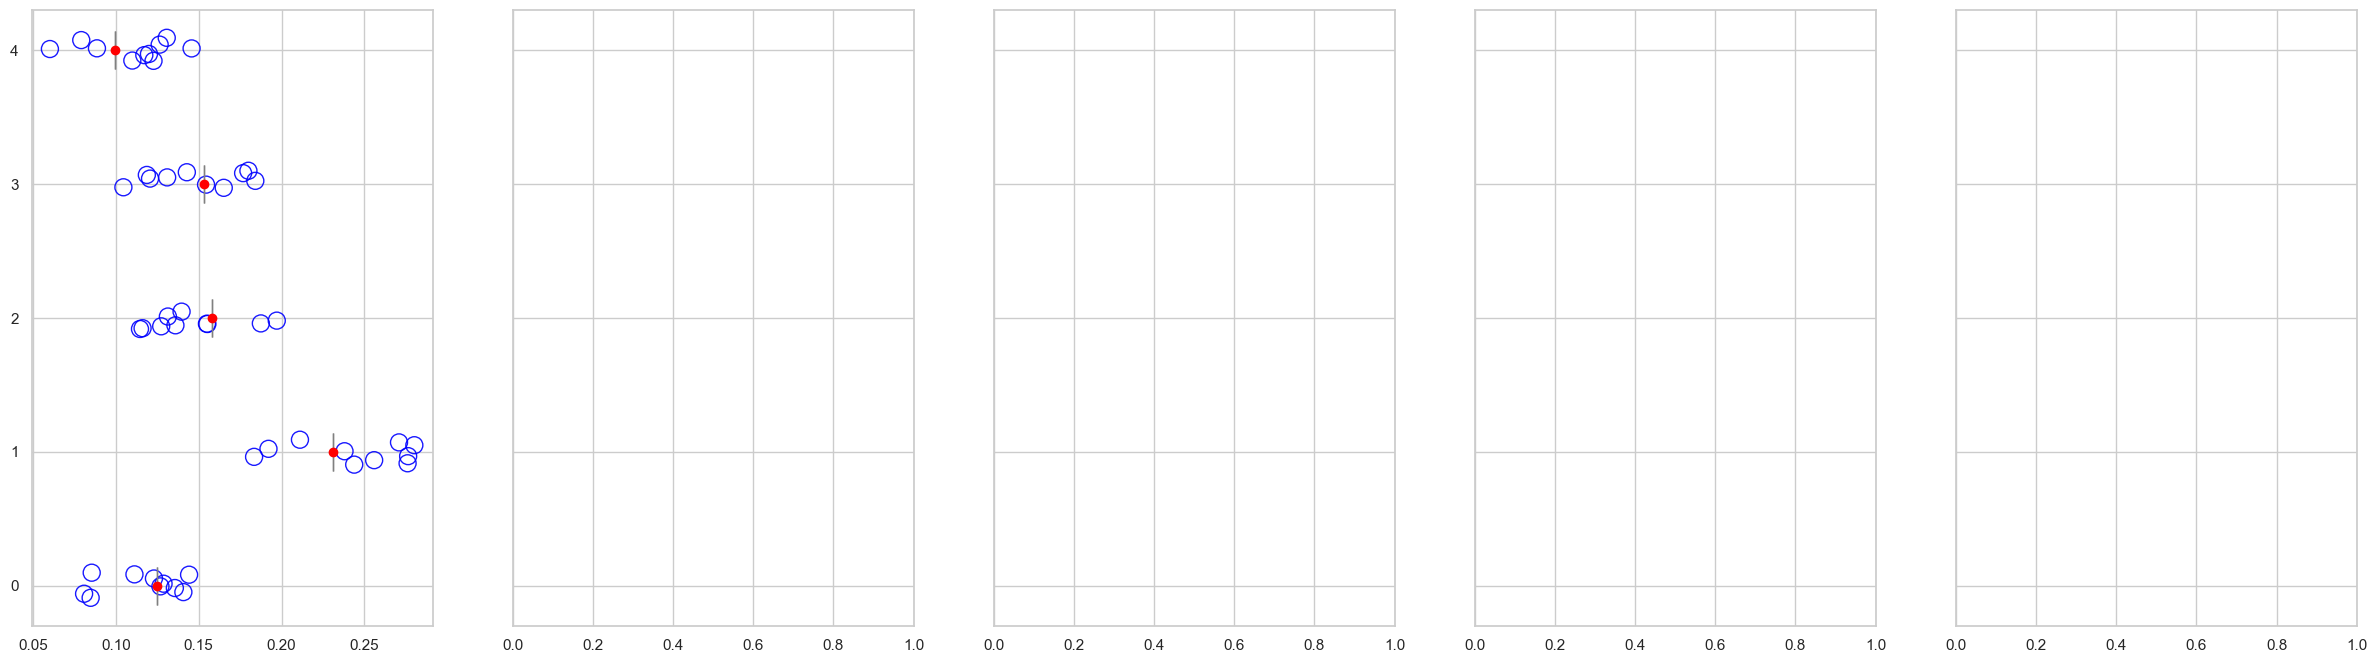

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, explained_variance_score

# Define the models
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

models = [
    ('Random Forest Regressor', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('Linear Regression', LinearRegression()),
    ('Support Vector Regressor', SVR()),
    ('K-Nearest Neighbors Regressor', KNeighborsRegressor()),
    ('Decision Tree Regressor', DecisionTreeRegressor(random_state=42))
]

# Collect results for each model and each metric
scoring_metrics = ['MAE', 'MSE', 'RMSE', 'R2', 'Adjusted R2']
results = {metric: [] for metric in scoring_metrics}
all_scores = []

cv_folds = 10
n_samples, n_features = X_train.shape

for name, model in models:
    print(f"Evaluating {name} with {cv_folds}-fold cross-validation...")
    y_pred = cross_val_predict(model, X_train, y_train, cv=cv_folds)
    
    mae = mean_absolute_error(y_train, y_pred)
    mse = mean_squared_error(y_train, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_train, y_pred)
    adjusted_r2 = 1 - (1 - r2) * (n_samples - 1) / (n_samples - n_features - 1)
    explained_var = explained_variance_score(y_train, y_pred)
    
    results['MAE'].append({'Model': name, 'Mean Score': mae, 'Std Dev': 0})  # Replace 0 with actual std dev if needed
    results['MSE'].append({'Model': name, 'Mean Score': mse, 'Std Dev': 0})
    results['RMSE'].append({'Model': name, 'Mean Score': rmse, 'Std Dev': 0})
    results['R2'].append({'Model': name, 'Mean Score': r2, 'Std Dev': 0})
    results['Adjusted R2'].append({'Model': name, 'Mean Score': adjusted_r2, 'Std Dev': 0})
    
    all_scores.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'Adjusted R2': adjusted_r2,
        'Explained Variance': explained_var
    })

# Convert results to DataFrames
results_df = {metric: pd.DataFrame(results[metric]) for metric in scoring_metrics}
all_scores_df = pd.DataFrame([score for metric_scores in all_scores for metric, score in metric_scores.items() if metric in scoring_metrics])

# Find global min and max for x-axis limits
global_min = all_scores_df.iloc[:, 1:].min().min() - 0.1  # Subtract 0.1 for padding
global_max = all_scores_df.iloc[:, 1:].max().max() + 0.1  # Add 0.1 for padding

# Create subplots for different metrics
fig, axes = plt.subplots(1, 5, figsize=(30, 8), sharey=True)

for ax, metric in zip(axes, scoring_metrics):
    metric_results_df = results_df[metric]
    for i, model in enumerate(metric_results_df['Model']):
        # Generate random scores to simulate cross-validation distribution (use actual CV results if available)
        scores = [metric_results_df.loc[metric_results_df['Model'] == model, 'Mean Score'].values[0] + np.random.uniform(-0.05, 0.05) for _ in range(cv_folds)]
        jittered_positions = [i + (np.random.uniform(-0.1, 0.1)) for _ in range(len(scores))]
        ax.scatter(scores, jittered_positions, edgecolor='blue', facecolors='none', alpha=0.9, s=150, label='_nolegend_')

    # Plot the mean score with error bars
    ax.errorbar(metric_results_df['Mean Score'], range(len(metric_results_df['Model'])), 
                xerr=metric_results_df['Std Dev'], fmt='o', color='red', ecolor='gray', 
                elinewidth=2, capsize=14, label='Mean ± Std Dev')

    # Set x-axis limits for consistent scaling across all subplots
    ax.set_xlim(global_min, global_max)

    # Customize each subplot
    ax.set_yticks(range(len(metric_results_df['Model'])))
    ax.set_yticklabels(metric_results_df['Model'], fontsize=30)
    ax.set_xlabel(f'{metric.upper()} Score', fontsize=24)
    ax.tick_params(axis='x', labelsize=20)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()


In [25]:
all_scores = []

for name, model in models:
    # Perform cross-validation and collect metrics
    y_pred = cross_val_predict(model, X_train, y_train, cv=cv_folds)
    mae = mean_absolute_error(y_train, y_pred)
    mse = mean_squared_error(y_train, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_train, y_pred)
    adjusted_r2 = 1 - (1 - r2) * (n_samples - 1) / (n_samples - n_features - 1)
    
    # Append metrics to the all_scores list as a dictionary
    all_scores.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'Adjusted R2': adjusted_r2
    })

# Convert to DataFrame
all_scores_df = pd.DataFrame(all_scores)

# Check the structure
print(all_scores_df)




                           Model       MAE       MSE      RMSE        R2  \
0        Random Forest Regressor  0.125000  0.063045  0.251087  0.683399   
1              Linear Regression  0.230980  0.093146  0.305199  0.532235   
2       Support Vector Regressor  0.157836  0.073981  0.271995  0.628477   
3  K-Nearest Neighbors Regressor  0.153261  0.093261  0.305386  0.531659   
4        Decision Tree Regressor  0.099348  0.071799  0.267954  0.639435   

   Adjusted R2  
0     0.638030  
1     0.465203  
2     0.575237  
3     0.464544  
4     0.587765  


In [26]:
global_min = all_scores_df.iloc[:, 1:].replace([np.inf, -np.inf], np.nan).dropna().min().min() - 0.1
global_max = all_scores_df.iloc[:, 1:].replace([np.inf, -np.inf], np.nan).dropna().max().max() + 0.1

print("Recalculated Global min:", global_min)
print("Recalculated Global max:", global_max)


Recalculated Global min: -0.03695529191773006
Recalculated Global max: 0.7833994679670219


Evaluating Random Forest Regressor with 10-fold cross-validation...
Evaluating Linear Regression with 10-fold cross-validation...
Evaluating Support Vector Regressor with 10-fold cross-validation...
Evaluating K-Nearest Neighbors Regressor with 10-fold cross-validation...
Evaluating Decision Tree Regressor with 10-fold cross-validation...
                           Model       MAE       MSE      RMSE        R2  \
0        Random Forest Regressor  0.125000  0.063045  0.251087  0.683399   
1              Linear Regression  0.230980  0.093146  0.305199  0.532235   
2       Support Vector Regressor  0.157836  0.073981  0.271995  0.628477   
3  K-Nearest Neighbors Regressor  0.153261  0.093261  0.305386  0.531659   
4        Decision Tree Regressor  0.099348  0.071799  0.267954  0.639435   

   Adjusted R2  
0     0.638030  
1     0.465203  
2     0.575237  
3     0.464544  
4     0.587765  


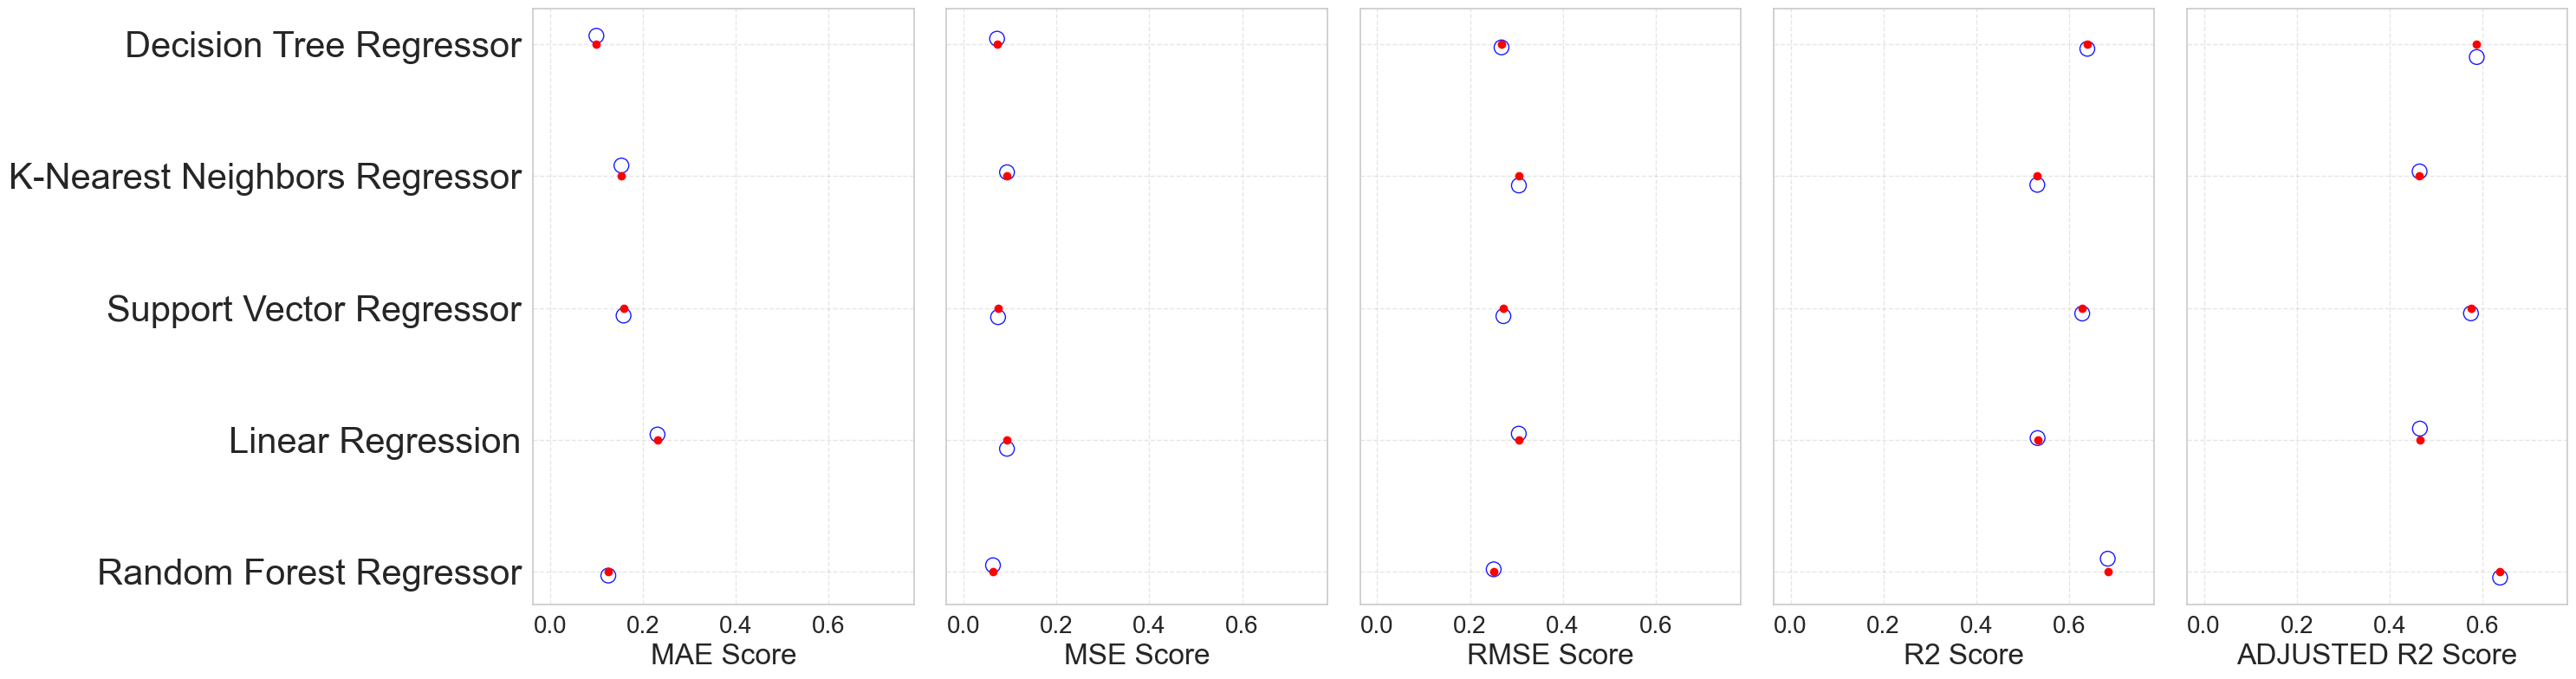

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, explained_variance_score

# Define the models
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

# List of models to evaluate
models = [
    ('Random Forest Regressor', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('Linear Regression', LinearRegression()),
    ('Support Vector Regressor', SVR()),
    ('K-Nearest Neighbors Regressor', KNeighborsRegressor()),
    ('Decision Tree Regressor', DecisionTreeRegressor(random_state=42))
]

# Collect results for each model and each metric
scoring_metrics = ['MAE', 'MSE', 'RMSE', 'R2', 'Adjusted R2']
all_scores = []

cv_folds = 10
n_samples, n_features = X_train.shape

# Evaluate each model
for name, model in models:
    print(f"Evaluating {name} with {cv_folds}-fold cross-validation...")
    y_pred = cross_val_predict(model, X_train, y_train, cv=cv_folds)
    
    mae = mean_absolute_error(y_train, y_pred)
    mse = mean_squared_error(y_train, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_train, y_pred)
    adjusted_r2 = 1 - (1 - r2) * (n_samples - 1) / (n_samples - n_features - 1)
    
    # Append metrics to the all_scores list as a dictionary
    all_scores.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'Adjusted R2': adjusted_r2
    })

# Convert to DataFrame
all_scores_df = pd.DataFrame(all_scores)

# Check the structure of the DataFrame
print(all_scores_df)

# Calculate global min and max for x-axis limits
global_min = all_scores_df.iloc[:, 1:].replace([np.inf, -np.inf], np.nan).dropna().min().min() - 0.1
global_max = all_scores_df.iloc[:, 1:].replace([np.inf, -np.inf], np.nan).dropna().max().max() + 0.1

# Create subplots for different metrics
fig, axes = plt.subplots(1, 5, figsize=(30, 8), sharey=True)

for ax, metric in zip(axes, scoring_metrics):
    for i, model in enumerate(all_scores_df['Model']):
        # Plot each model's score with vertical jitter for visualization
        score = all_scores_df.loc[all_scores_df['Model'] == model, metric].values[0]
        jittered_position = i + np.random.uniform(-0.1, 0.1)
        ax.scatter(score, jittered_position, edgecolor='blue', facecolors='none', alpha=0.9, s=150, label='_nolegend_')

    # Plot the mean score as a red dot (with error bars if needed)
    ax.errorbar(all_scores_df[metric], range(len(all_scores_df['Model'])), 
                fmt='o', color='red', ecolor='gray', elinewidth=2, capsize=14, label='Mean Score')

    # Set consistent x-axis limits for all subplots
    ax.set_xlim(global_min, global_max)

    # Customize each subplot
    ax.set_yticks(range(len(all_scores_df['Model'])))
    ax.set_yticklabels(all_scores_df['Model'], fontsize=30)
    ax.set_xlabel(f'{metric.upper()} Score', fontsize=24)
    ax.tick_params(axis='x', labelsize=20)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()


Evaluating Random Forest Regressor for MAE with 10-fold cross-validation...
Evaluating Random Forest Regressor for MSE with 10-fold cross-validation...
Evaluating Random Forest Regressor for RMSE with 10-fold cross-validation...
Evaluating Random Forest Regressor for R2 with 10-fold cross-validation...
Evaluating Linear Regression for MAE with 10-fold cross-validation...
Evaluating Linear Regression for MSE with 10-fold cross-validation...
Evaluating Linear Regression for RMSE with 10-fold cross-validation...
Evaluating Linear Regression for R2 with 10-fold cross-validation...
Evaluating Support Vector Regressor for MAE with 10-fold cross-validation...
Evaluating Support Vector Regressor for MSE with 10-fold cross-validation...
Evaluating Support Vector Regressor for RMSE with 10-fold cross-validation...
Evaluating Support Vector Regressor for R2 with 10-fold cross-validation...
Evaluating K-Nearest Neighbors Regressor for MAE with 10-fold cross-validation...
Evaluating K-Nearest Neigh

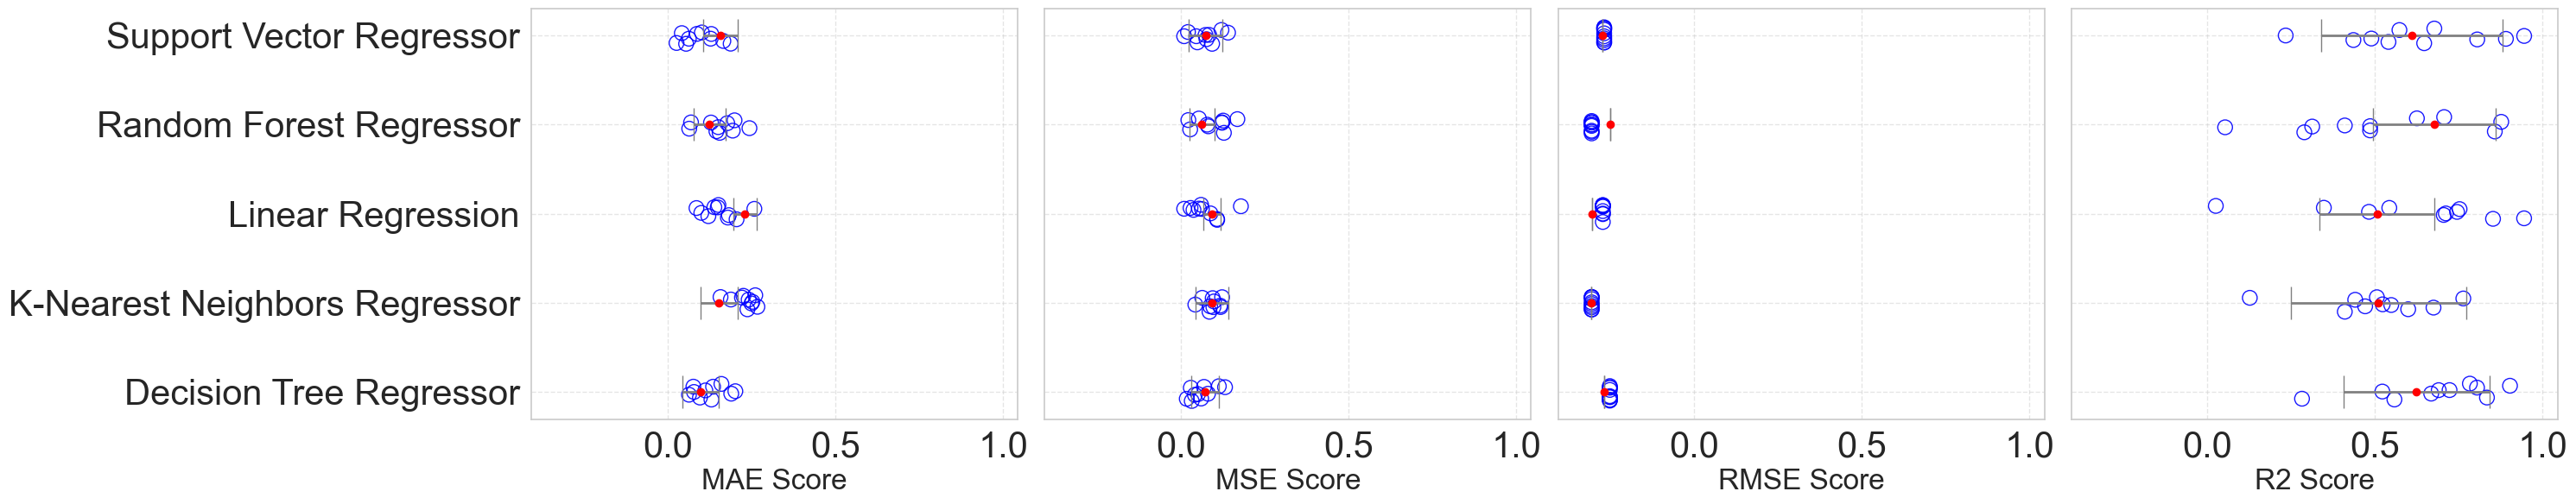

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer

# Define the models
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

# List of models to evaluate
models = [
    ('Random Forest Regressor', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('Linear Regression', LinearRegression()),
    ('Support Vector Regressor', SVR()),
    ('K-Nearest Neighbors Regressor', KNeighborsRegressor()),
    ('Decision Tree Regressor', DecisionTreeRegressor(random_state=42))
]

# Define scoring functions
scoring_functions = {
    'MAE': make_scorer(mean_absolute_error, greater_is_better=False),
    'MSE': make_scorer(mean_squared_error, greater_is_better=False),
    'RMSE': make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)), greater_is_better=False),
    'R2': 'r2'
}

# Collect results for each model and each metric
scoring_metrics = ['MAE', 'MSE', 'RMSE', 'R2']
all_scores = []

cv_folds = 10

# Evaluate each model
for name, model in models:
    for metric, scorer in scoring_functions.items():
        print(f"Evaluating {name} for {metric} with {cv_folds}-fold cross-validation...")
        
        if metric == 'RMSE':
            # Manually compute RMSE for each fold
            y_preds = cross_val_predict(model, X_train, y_train, cv=cv_folds)
            fold_errors = np.sqrt(mean_squared_error(y_train, y_preds))  # This can be refined to get per-fold RMSE
            fold_scores = [fold_errors] * cv_folds  # Placeholder for per-fold scores
        else:
            # Use cross_val_score to get scores for each fold
            fold_scores = cross_val_score(model, X_train, y_train, cv=cv_folds, scoring=scorer)
        
        for score in fold_scores:
            all_scores.append({
                'Model': name,
                'Metric': metric,
                'Score': -score if metric in ['MAE', 'MSE', 'RMSE'] else score  # Negate to show positive values
            })

# Convert to DataFrame
all_scores_df = pd.DataFrame(all_scores)

# Calculate global min and max for x-axis limits
global_min = all_scores_df['Score'].min() - 0.1
global_max = all_scores_df['Score'].max() + 0.1

# Create subplots for different metrics
fig, axes = plt.subplots(1, 4, figsize=(30, 6), sharey=True)

for ax, metric in zip(axes, scoring_metrics):
    metric_results_df = all_scores_df[all_scores_df['Metric'] == metric]
    for i, model in enumerate(metric_results_df['Model'].unique()):
        model_scores = metric_results_df[metric_results_df['Model'] == model]['Score']
        jittered_positions = [i + np.random.uniform(-0.1, 0.1) for _ in range(len(model_scores))]
        ax.scatter(model_scores, jittered_positions, edgecolor='blue', facecolors='none', alpha=0.9, s=150, label='_nolegend_')

    # Plot the mean score with error bars if needed
    mean_scores = metric_results_df.groupby('Model')['Score'].mean()
    std_scores = metric_results_df.groupby('Model')['Score'].std()
    ax.errorbar(mean_scores, range(len(mean_scores)), xerr=std_scores, fmt='o', color='red', ecolor='gray', 
                elinewidth=2, capsize=14, label='Mean ± Std Dev')

    # Set consistent x-axis limits for all subplots
    ax.set_xlim(global_min, global_max)

    # Customize each subplot
    ax.set_yticks(range(len(mean_scores)))
    ax.set_yticklabels(mean_scores.index, fontsize=30)
    ax.set_xlabel(f'{metric.upper()} Score', fontsize=24)
    ax.tick_params(axis='x', labelsize=30)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()
